In [3]:
# 1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import recall_score, roc_auc_score, confusion_matrix, PrecisionRecallDisplay, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

In [4]:
# 2. DATA INGESTION & PREPROCESSING
url1 = "g:\\PythonS\\DataScience\\ML\\creditcard.csv"
raw_data = pd.read_csv(url1)

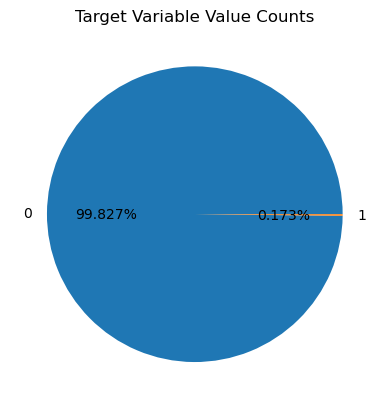

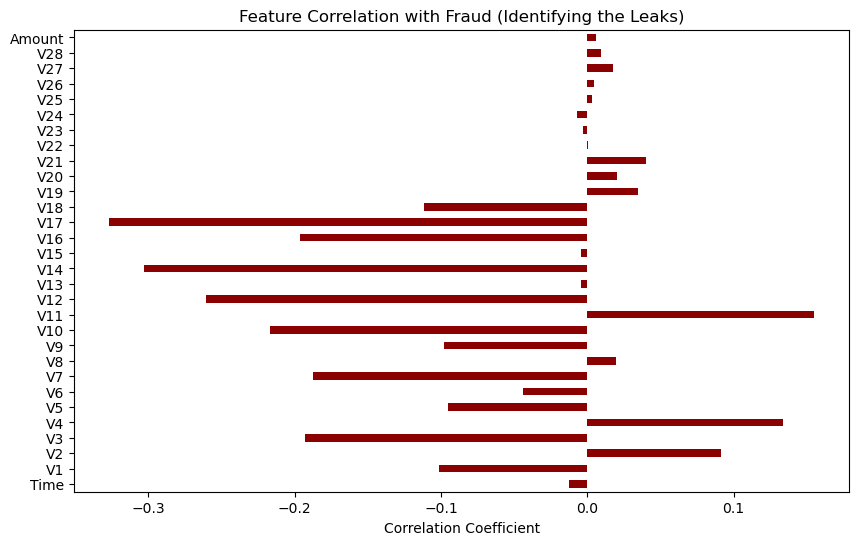

Top 6 High-Impact Features Identified: ['V17', 'V14', 'V12', 'V10', 'V16', 'V3']

 FORENSIC AUDIT: BASELINE (All) vs. OPTIMIZED (Top 6)

DECISION TREE:
  All Features -> ROC-AUC: 0.939 | Recall: 0.875
  Top 6 Only   -> ROC-AUC: 0.952 | Recall: 0.890

SUPPORT VECTOR MACHINE (SVM):
  All Features -> ROC-AUC: 0.986 | Recall: 0.978
  Top 6 Only   -> ROC-AUC: 0.937 | Recall: 0.978

--- BUSINESS IMPACT (SVM Top 6 Features) ---
Thieves Caught (TP): 133 (Saved ₹665,000)
Innocents Blocked (FP): 36368 (Lost ₹43,641,600)
Cost-Benefit Ratio (CBR): 0.015


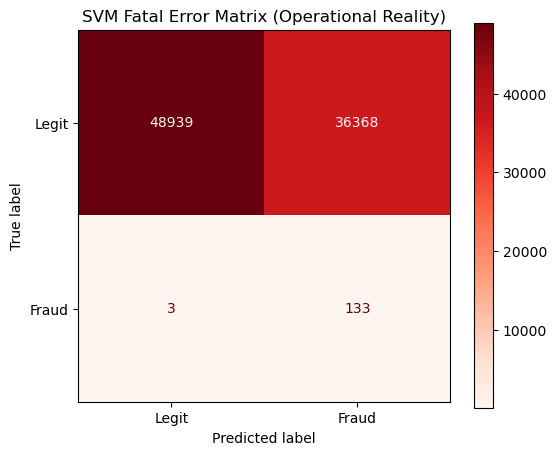

In [5]:

#EDA 
labels = raw_data.Class.unique() 
# get the count of each class
sizes = raw_data.Class.value_counts().values 
# plot the class value counts 
fig, ax = plt.subplots() 
ax.pie(sizes, labels=labels, autopct='%1.3f%%')  
ax.set_title('Target Variable Value Counts') 
plt.show() 

# Standardize the features (excluding Time and Class)
raw_data.iloc[:, 1:30] = StandardScaler().fit_transform(raw_data.iloc[:, 1:30])
data_matrix = raw_data.values
y = data_matrix[:, 30]

# 3. THE CORRELATION AUDIT (Visualizing the "Signal")
plt.figure(figsize=(10, 6))
corr_values = raw_data.corr()['Class'].drop('Class')
corr_values.plot(kind='barh', color='darkred')
plt.title('Feature Correlation with Fraud (Identifying the Leaks)')
plt.xlabel('Correlation Coefficient')
plt.show()

# Get Top 6 highly correlated features
correlation_val = abs(raw_data.corr()['Class']).drop('Class')
top_6_features = correlation_val.sort_values(ascending=False)[:6].index.tolist()
print(f"Top 6 High-Impact Features Identified: {top_6_features}\n")

# 4. DATA SPLITS: BASELINE (All Features) vs. OPTIMIZED (Top 6)
# Baseline: All 29 features
X_all = normalize(data_matrix[:, 1:30], norm="l1")
X_train_all, X_test_all, y_train, y_test = train_test_split(X_all, y, test_size=0.3, random_state=42)

# Optimized: Top 6 features (Indices: 3, 10, 12, 14, 16, 17)
X_6f = normalize(data_matrix[:, [3, 10, 12, 14, 16, 17]], norm="l1")
X_train_6f, X_test_6f, y_train, y_test = train_test_split(X_6f, raw_data['Class'],test_size=0.3, random_state=42)

# Class Weights (Shared)
w_train = compute_sample_weight('balanced', y_train)

# 5. MODEL TRAINING (BASELINE: ALL FEATURES)
dt_all = DecisionTreeClassifier(max_depth=4, random_state=35)
dt_all.fit(X_train_all, y_train, sample_weight=w_train)

svm_all = LinearSVC(class_weight='balanced', random_state=31, loss="hinge", fit_intercept=False)
svm_all.fit(X_train_all, y_train)

# 6. MODEL TRAINING (OPTIMIZED: TOP 6 FEATURES)
dt_6f = DecisionTreeClassifier(max_depth=4, random_state=35)
dt_6f.fit(X_train_6f, y_train, sample_weight=w_train)

svm_6f = LinearSVC(class_weight='balanced', random_state=31, loss="hinge", fit_intercept=False)
svm_6f.fit(X_train_6f, y_train)

# 7. FORENSIC COMPARISON & EVALUATION
print("==========================================================")
print(" FORENSIC AUDIT: BASELINE (All) vs. OPTIMIZED (Top 6)")
print("==========================================================\n")

# DT Metrics
print("DECISION TREE:")
print(f"  All Features -> ROC-AUC: {roc_auc_score(y_test, dt_all.predict_proba(X_test_all)[:, 1]):.3f} | Recall: {recall_score(y_test, dt_all.predict(X_test_all)):.3f}")
print(f"  Top 6 Only   -> ROC-AUC: {roc_auc_score(y_test, dt_6f.predict_proba(X_test_6f)[:, 1]):.3f} | Recall: {recall_score(y_test, dt_6f.predict(X_test_6f)):.3f}\n")

# SVM Metrics
print("SUPPORT VECTOR MACHINE (SVM):")
print(f"  All Features -> ROC-AUC: {roc_auc_score(y_test, svm_all.decision_function(X_test_all)):.3f} | Recall: {recall_score(y_test, svm_all.predict(X_test_all)):.3f}")
print(f"  Top 6 Only   -> ROC-AUC: {roc_auc_score(y_test, svm_6f.decision_function(X_test_6f)):.3f} | Recall: {recall_score(y_test, svm_6f.predict(X_test_6f)):.3f}\n")

# 8. BUSINESS RISK (COST-BENEFIT RATIO) FOR THE WINNING MODEL (SVM - Top 6)
y_pred_svm_6f_bin = svm_6f.predict(X_test_6f)
cm = confusion_matrix(y_test, y_pred_svm_6f_bin)
tn, fp, fn, tp = cm.ravel()

fraud_loss, fp_cost = 5000, 1200
benefits, costs = tp * fraud_loss, fp * fp_cost
cbr = benefits / costs if costs > 0 else 0

print("--- BUSINESS IMPACT (SVM Top 6 Features) ---")
print(f"Thieves Caught (TP): {tp} (Saved ₹{benefits:,})")
print(f"Innocents Blocked (FP): {fp} (Lost ₹{costs:,})")
print(f"Cost-Benefit Ratio (CBR): {cbr:.3f}")

# 9. VISUALIZING THE "NASTY" ERROR MATRIX
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud']).plot(cmap='Reds', values_format='d', ax=ax)
ax.set_title("SVM Fatal Error Matrix (Operational Reality)")
plt.show()

In [7]:

# 1. Create the 'Clean' reference for amounts before they were scaled
# Ensure this 'raw_data_original' is the version before StandardScaler was applied
raw_data_original = pd.read_csv(url1) 

# 2. Extract the unscaled amounts using the same test indices
unscaled_amounts_test = raw_data_original.loc[y_test.index, 'Amount'].values

# 3. Re-build the Results DF with actual currency
results_df_real = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_svm_6f_bin,
    'Amount': unscaled_amounts_test
})

# 4. Re-calculate Financial Audit
money_saved = results_df_real[(results_df_real['Actual'] == 1) & (results_df_real['Predicted'] == 1)]['Amount'].sum()
money_leaked = results_df_real[(results_df_real['Actual'] == 1) & (results_df_real['Predicted'] == 0)]['Amount'].sum()
fp_count = results_df_real[(results_df_real['Actual'] == 0) & (results_df_real['Predicted'] == 1)].shape[0]

# Operational damage: Still using the flat ₹1200 'insult cost' per customer
operational_damage = fp_count * 1200
real_cbr = money_saved / (money_leaked + operational_damage)

print("--- FINAL FINANCIAL AUDIT (UNSCALED) ---")
print(f"Money Saved: ₹{money_saved:,.2f}")
print(f"Money Leaked: ₹{money_leaked:,.2f}")
print(f"Operational Damage: ₹{operational_damage:,.2f}")
print(f"CBR: {real_cbr:.8f}")


# Find the 5 largest FRAUDS that the model MISSED (False Negatives)
missed_frauds = results_df_real[(results_df_real['Actual'] == 1) & (results_df_real['Predicted'] == 0)]
big_misses = missed_frauds.sort_values(by='Amount', ascending=False).head(5)

print("--- TOP 5 MISSED FRAUDS (THE BIG FISH) ---")
print(big_misses if not big_misses.empty else "No frauds missed! Clean sweep.")



--- FINAL FINANCIAL AUDIT (UNSCALED) ---
Money Saved: ₹17,956.32
Money Leaked: ₹1,617.65
Operational Damage: ₹43,641,600.00
CBR: 0.00041143
--- TOP 5 MISSED FRAUDS (THE BIG FISH) ---
       Actual  Predicted   Amount
3228        1          0  1096.99
17388       1          0   519.90
8379        1          0     0.76


In [8]:
# 1. Get raw SVM scores
y_scores = svm_6f.decision_function(X_test_6f)

# 2. Fix the "Big Fish" Typo and display
missed_frauds = results_df_real[(results_df_real['Actual'] == 1) & (results_df_real['Predicted'] == 0)]
big_misses = missed_frauds.sort_values(by='Amount', ascending=False).head(5)

print("--- TOP 5 MISSED FRAUDS (RECOVERY AUDIT) ---")
print(big_misses if not big_misses.empty else "No frauds missed.")

# 3. Find the Golden Threshold
threshold_range = np.linspace(-1, 5, 200)
net_profits = []

for t in threshold_range:
    preds = (y_scores > t).astype(int)
    
    # Financials for this threshold
    tp_mask = (y_test == 1) & (preds == 1)
    money_saved = results_df_real.loc[tp_mask.values, 'Amount'].sum() # .values ensures alignment
    
    fp_count = ((y_test == 0) & (preds == 1)).sum()
    operational_damage = fp_count * 1200 # 1200 charge by CC (insult cost)
    
    net_profits.append(money_saved - operational_damage)

# 4. Final Verdict
best_index = np.argmax(net_profits)
best_threshold = threshold_range[best_index]
max_profit = net_profits[best_index]

print(f"\nOptimal Threshold: {best_threshold:.4f}")
print(f"Maximum Possible Profit: ₹{max_profit:,.2f}")

if max_profit > 0:
    print("STATUS: PROFITABLE RISK ASSET ✅")
else:
    print("STATUS: FINANCIAL LIABILITY ❌")

--- TOP 5 MISSED FRAUDS (RECOVERY AUDIT) ---
       Actual  Predicted   Amount
3228        1          0  1096.99
17388       1          0   519.90
8379        1          0     0.76

Optimal Threshold: 2.4070
Maximum Possible Profit: ₹0.00
STATUS: FINANCIAL LIABILITY ❌
